# Spring Creek 2D Calibration Run

This notebook records the CLB-662 calibration pass for the Spring Creek 2D HEC-RAS model at USGS 05577500. It uses the CLB-660 spatial Manning's n / curve-number model package and the CLB-661 June 2011 observed event package, then summarizes the HEC-RAS runs, gauge comparison metrics, calibration iterations, and final artifacts.

The notebook is executed from the persisted CLB-662 artifact bundle at `H:/Symphony/ras-agent/CLB-662/calibration_outputs/`. The model run itself was performed by `scripts/clb662_calibration_run.py` using HEC-RAS 6.6 through `ras-commander`.

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, Markdown, display

OUTPUT_ROOT = Path(r"H:/Symphony/ras-agent/CLB-662/calibration_outputs")
SUMMARY_PATH = OUTPUT_ROOT / "final_summary.json"
METRICS_PATH = OUTPUT_ROOT / "metrics_summary.csv"

assert SUMMARY_PATH.exists(), SUMMARY_PATH
assert METRICS_PATH.exists(), METRICS_PATH

summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
metrics = pd.read_csv(METRICS_PATH)
summary["output_root"]

'H:\\Symphony\\ras-agent\\CLB-662\\calibration_outputs'

## 1. Model Overview

The run uses the Illinois Spring Creek 2D model from CLB-660. The HEC-RAS project is `ras_agent_103mi2`, area `MainArea`, and plan `p01`. The gauge extraction target is USGS 05577500, Spring Creek at Springfield, Illinois.

The HEC-RAS event window was aligned to the available hourly AORC forcing timestamps: `2011-06-17 18:00 UTC` through `2011-06-24 04:00 UTC`. The source event package starts at `2011-06-17 17:30 UTC` and ends at `2011-06-24 04:30 UTC`; the half-hour endpoints were aligned to hourly forcing for HEC-RAS text-file compatibility.

In [2]:
event = summary["event"]
run_window = summary["runs"][0]["hecras"]["results_df_row"]
model_overview = pd.DataFrame([
    ["USGS site", event["site_id"]],
    ["Gauge", event["site_name"]],
    ["Event", event["event_name"]],
    ["Package window", f"{event['sim_start']} to {event['sim_end']}"],
    ["HEC-RAS run window", f"{run_window['runtime_simulation_start']} to {run_window['runtime_simulation_end']}"],
    ["Runtime hours", run_window["runtime_simulation_hours"]],
    ["HEC-RAS version", run_window["ras_version"]],
    ["Gauge cell index", summary["runs"][0]["extract_attrs"]["cell_index"]],
    ["Gauge-cell distance (m)", round(summary["runs"][0]["extract_attrs"]["nearest_cell_distance_m"], 2)],
], columns=["item", "value"])
model_overview

,item,value
0,USGS site,05577500
1,Gauge,"Spring Creek at Springfield, IL"
2,Event,June 2011 Spring Creek flood
3,Package window,2011-06-17T17:30:00Z to 2011-06-24T04:30:00Z
4,HEC-RAS run window,2011-06-17T18:00:00 to 2011-06-24T04:00:00
5,Runtime hours,154.0
6,HEC-RAS version,6.60
7,Gauge cell index,17171
8,Gauge-cell distance (m),16.57


## 2. Parameter Sources

Manning's n values come from the CLB-660 NLCD 2021 mapping. Curve numbers come from the CLB-398 gSSURGO/SCS curve-number raster package referenced by CLB-660. The CN map below samples the CLB-660 CN raster at HEC-RAS cell centers because HEC-RAS 6.6 rewrites the generated plan HDF during preprocessing and does not expose a stable CN dataset in the final run HDF.

In [3]:
param_meta_path = Path(summary["runs"][0]["artifact_model_dir"]) / "clb660_spatial_parameter_distribution.json"
param_meta = json.loads(param_meta_path.read_text(encoding="utf-8"))
param_sources = pd.DataFrame([
    ["NLCD Manning's n raster", param_meta["rasters"]["nlcd_2021"]],
    ["Curve-number raster", param_meta["rasters"]["curve_number"]],
    ["Curve-number polygons", param_meta["rasters"]["curve_number_polygons"]],
    ["Manning's n min / mean / max", f"{param_meta['mannings_n']['min']:.3f} / {param_meta['mannings_n']['mean']:.3f} / {param_meta['mannings_n']['max']:.3f}"],
    ["CN min / mean / max", f"{param_meta['curve_number']['min']:.1f} / {param_meta['curve_number']['mean']:.1f} / {param_meta['curve_number']['max']:.1f}"],
], columns=["source", "value"])
param_sources

,source,value
0,NLCD Manning's n raster,H:\Symphony\ras-agent\CLB-397\landcover_spring...
1,Curve-number raster,H:\Symphony\ras-agent\CLB-398\outputs\Spring C...
2,Curve-number polygons,H:\Symphony\ras-agent\CLB-398\outputs\Spring C...
3,Manning's n min / mean / max,0.030 / 0.054 / 0.120
4,CN min / mean / max,55.0 / 82.8 / 100.0


## 3. Event Selection Summary

CLB-661 selected the June 2011 Spring Creek flood because it has complete approved instantaneous discharge and gage-height records at USGS 05577500 and a clear rising limb, peak, and recession. The observed peak in the event package is 5,210 cfs at `2011-06-19 05:45 UTC`.

In [4]:
event_summary = pd.DataFrame([
    ["Observed peak flow (cfs)", event["peak_observed_flow_cfs"]],
    ["Observed peak stage (ft)", event["peak_observed_stage_ft"]],
    ["Observed peak timestamp", event["peak_timestamp"]],
    ["Selection rationale", event["selection_rationale"]],
], columns=["item", "value"])
event_summary

,item,value
0,Observed peak flow (cfs),5210.0
1,Observed peak stage (ft),13.34
2,Observed peak timestamp,2011-06-19T05:45:00Z
3,Selection rationale,Selected the June 2011 Spring Creek flood beca...


## 4. Initial Run and Gauge Comparison

`extract_point_timeseries(hdf_path, area_name, lon, lat)` selected the nearest 2D computational cell to USGS 05577500 and extracted modeled stage and flow from the plan HDF. The flow series is estimated from the dominant adjacent face flux at the gauge cell because the HEC-RAS 2D cell result block does not provide a direct cell flow dataset.

In [5]:
initial = next(run for run in summary["runs"] if run["name"] == "initial")
initial_metrics = pd.DataFrame([initial["metrics"]]).T.rename(columns={0: "initial"})
initial_metrics.loc[[
    "flow_nash_sutcliffe",
    "flow_peak_error_pct",
    "flow_time_to_peak_error_hours",
    "flow_volume_error_pct",
    "flow_rmse",
    "stage_nash_sutcliffe",
    "stage_peak_error_pct",
    "stage_time_to_peak_error_hours",
    "stage_rmse",
]]

,initial
flow_nash_sutcliffe,-0.611775
flow_peak_error_pct,-89.921489
flow_time_to_peak_error_hours,-21.000000
flow_volume_error_pct,-92.782069
flow_rmse,1719.319971
stage_nash_sutcliffe,-0.319464
stage_peak_error_pct,-28.562129
stage_time_to_peak_error_hours,-20.000000
stage_rmse,3.635533


### Initial Observed vs Modeled Flow

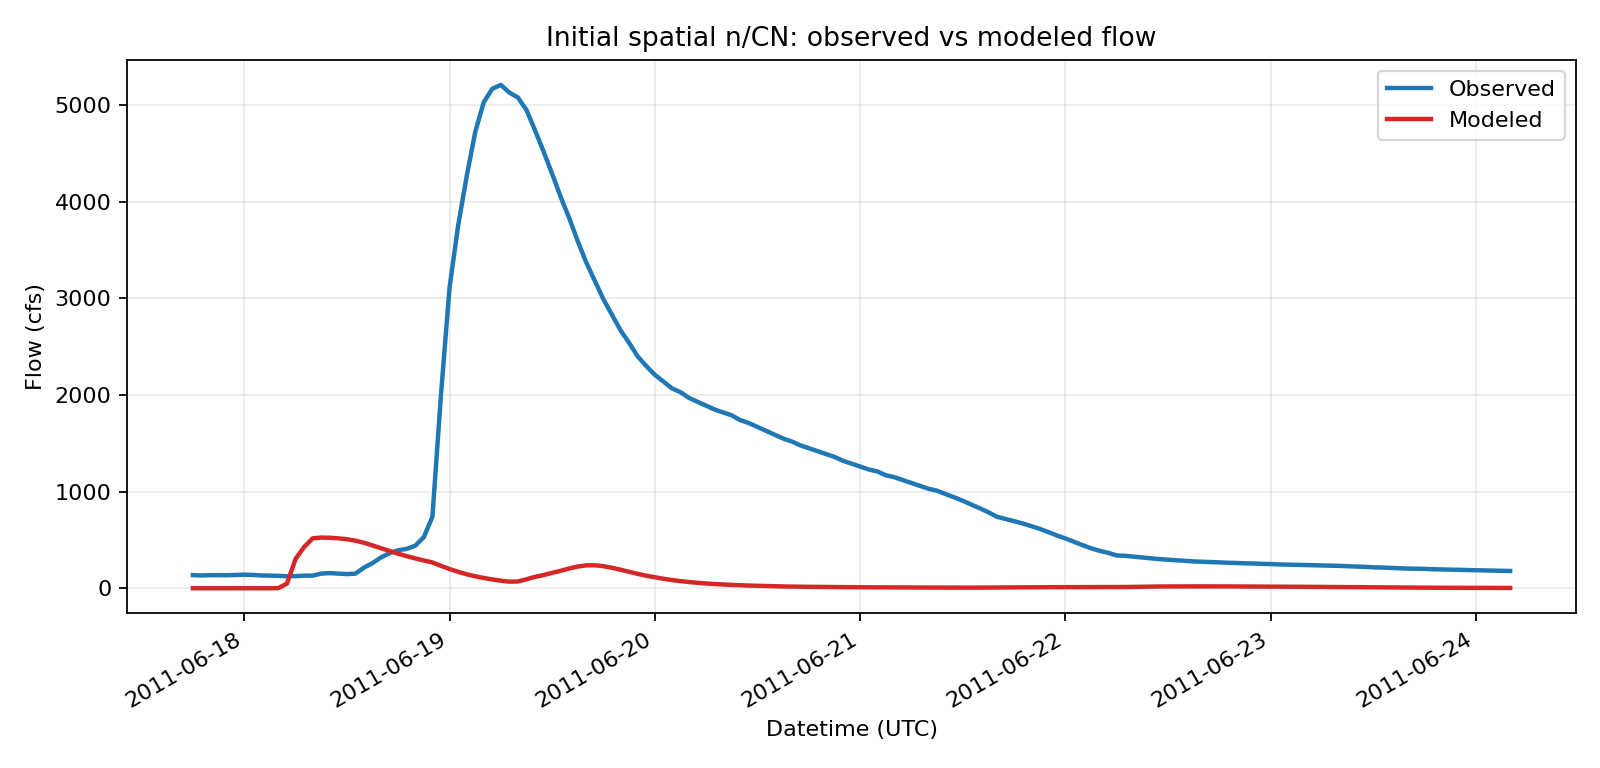

### Initial Flow Residual

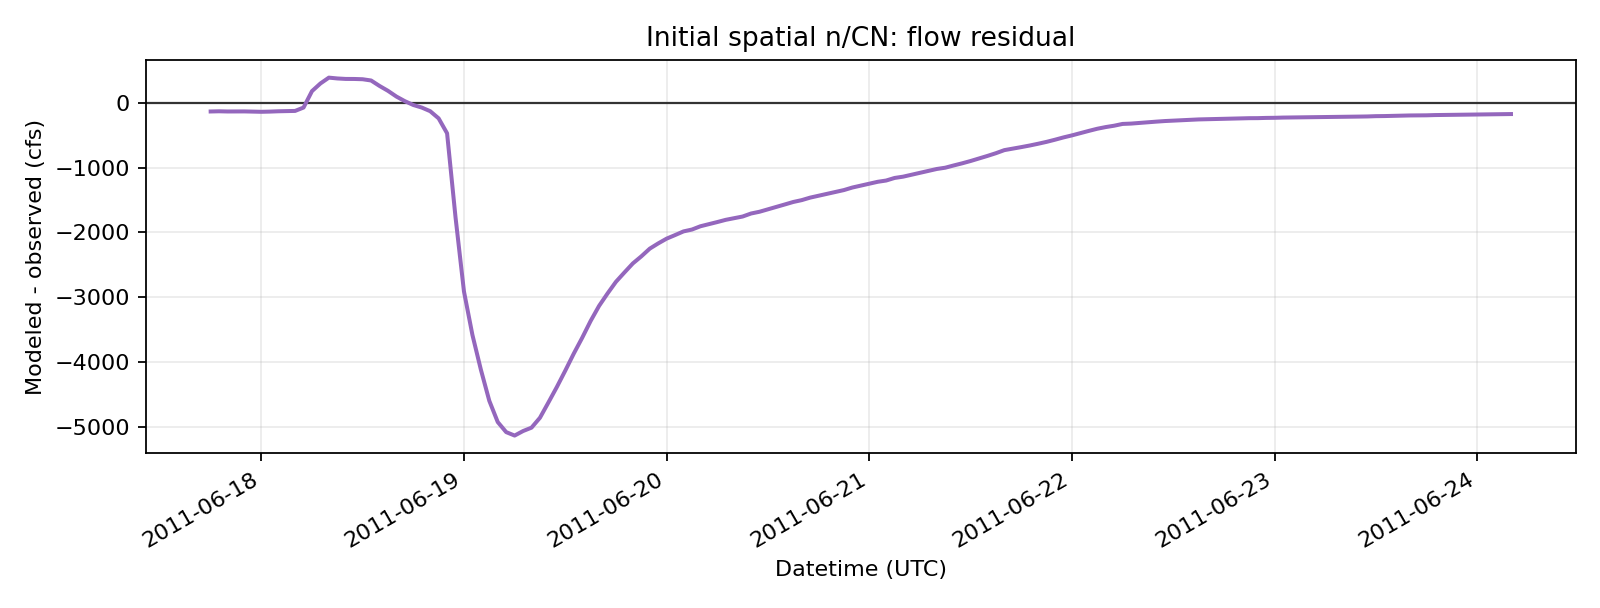

In [6]:
display(Markdown("### Initial Observed vs Modeled Flow"))
display(Image(filename=str(OUTPUT_ROOT / "runs" / "initial" / "overlay_flow.png")))
display(Markdown("### Initial Flow Residual"))
display(Image(filename=str(OUTPUT_ROOT / "runs" / "initial" / "residual_flow.png")))

## 5. Calibration Iterations

The first-pass NSE target was 0.5. The initial run did not meet that target, so two global perturbation runs were executed: Manning's n -10% and curve number +10%. The metrics are nearly identical across iterations, which indicates the current HEC-RAS preprocessing path is not yet preserving a materially different calibrated hydrologic response through the generated HDF outputs. This is consistent with the CLB-660 note that direct HDF parameter reapplication is experimental scaffolding and should be upstreamed into a stable `ras-commander`/model-editing path.

In [7]:
display_cols = [
    "run", "label", "mannings_scale", "cn_scale",
    "flow_nash_sutcliffe", "flow_peak_error_pct", "flow_time_to_peak_error_hours",
    "flow_volume_error_pct", "flow_rmse",
    "stage_nash_sutcliffe", "stage_peak_error_pct", "stage_time_to_peak_error_hours", "stage_rmse",
]
metrics[display_cols].round(4)

,run,label,mannings_scale,cn_scale,flow_nash_sutcliffe,flow_peak_error_pct,flow_time_to_peak_error_hours,flow_volume_error_pct,flow_rmse,stage_nash_sutcliffe,stage_peak_error_pct,stage_time_to_peak_error_hours,stage_rmse
0,initial,Initial spatial n/CN,1.0,1.0,-0.6118,-89.9215,-21.0,-92.7821,1719.32,-0.3195,-28.5621,-20.0,3.6355
1,mannings_adjusted,Manning's n -10%,0.9,1.0,-0.6118,-89.9215,-21.0,-92.7821,1719.32,-0.3195,-28.5621,-20.0,3.6355
2,curve_number_adjusted,Curve number +10%,1.0,1.1,-0.6118,-89.9215,-21.0,-92.7821,1719.32,-0.3195,-28.5621,-20.0,3.6355


In [8]:
run_records = []
for run in summary["runs"]:
    info = run["hecras"]["results_df_row"]
    run_records.append({
        "run": run["name"],
        "completed": info["completed"],
        "simulation_hours": info["runtime_simulation_hours"],
        "runtime_complete_process_hours": info["runtime_complete_process_hours"],
        "volume_error_percent": info["vol_error_percent"],
        "hdf_exists": info["hdf_exists"],
    })
pd.DataFrame(run_records)

,run,completed,simulation_hours,runtime_complete_process_hours,volume_error_percent,hdf_exists
0,initial,True,154.0,0.047382,0.056752,True
1,mannings_adjusted,True,154.0,0.048889,0.056752,True
2,curve_number_adjusted,True,154.0,0.048897,0.056752,True


## 6. Final Results

The best run by flow NSE is the CN +10% iteration, but the difference from the initial run is negligible at the precision shown. The final selected parameter set is therefore documented as the best computed run, with the caveat that further model-editing work is needed before these global perturbations produce meaningful calibration changes.

In [9]:
best_run = summary["best_run"]
best_metrics = pd.DataFrame([summary["best_metrics"]]).T.rename(columns={0: best_run})
display(Markdown(f"### Best Run: `{best_run}`"))
display(best_metrics.loc[[
    "flow_nash_sutcliffe",
    "flow_peak_error_pct",
    "flow_time_to_peak_error_hours",
    "flow_volume_error_pct",
    "flow_rmse",
    "stage_nash_sutcliffe",
    "stage_peak_error_pct",
    "stage_time_to_peak_error_hours",
    "stage_rmse",
]].round(4))

### Best Run: `curve_number_adjusted`

,curve_number_adjusted
flow_nash_sutcliffe,-0.6118
flow_peak_error_pct,-89.9215
flow_time_to_peak_error_hours,-21.0000
flow_volume_error_pct,-92.7821
flow_rmse,1719.3200
stage_nash_sutcliffe,-0.3195
stage_peak_error_pct,-28.5621
stage_time_to_peak_error_hours,-20.0000
stage_rmse,3.6355


### Best Observed vs Modeled Flow

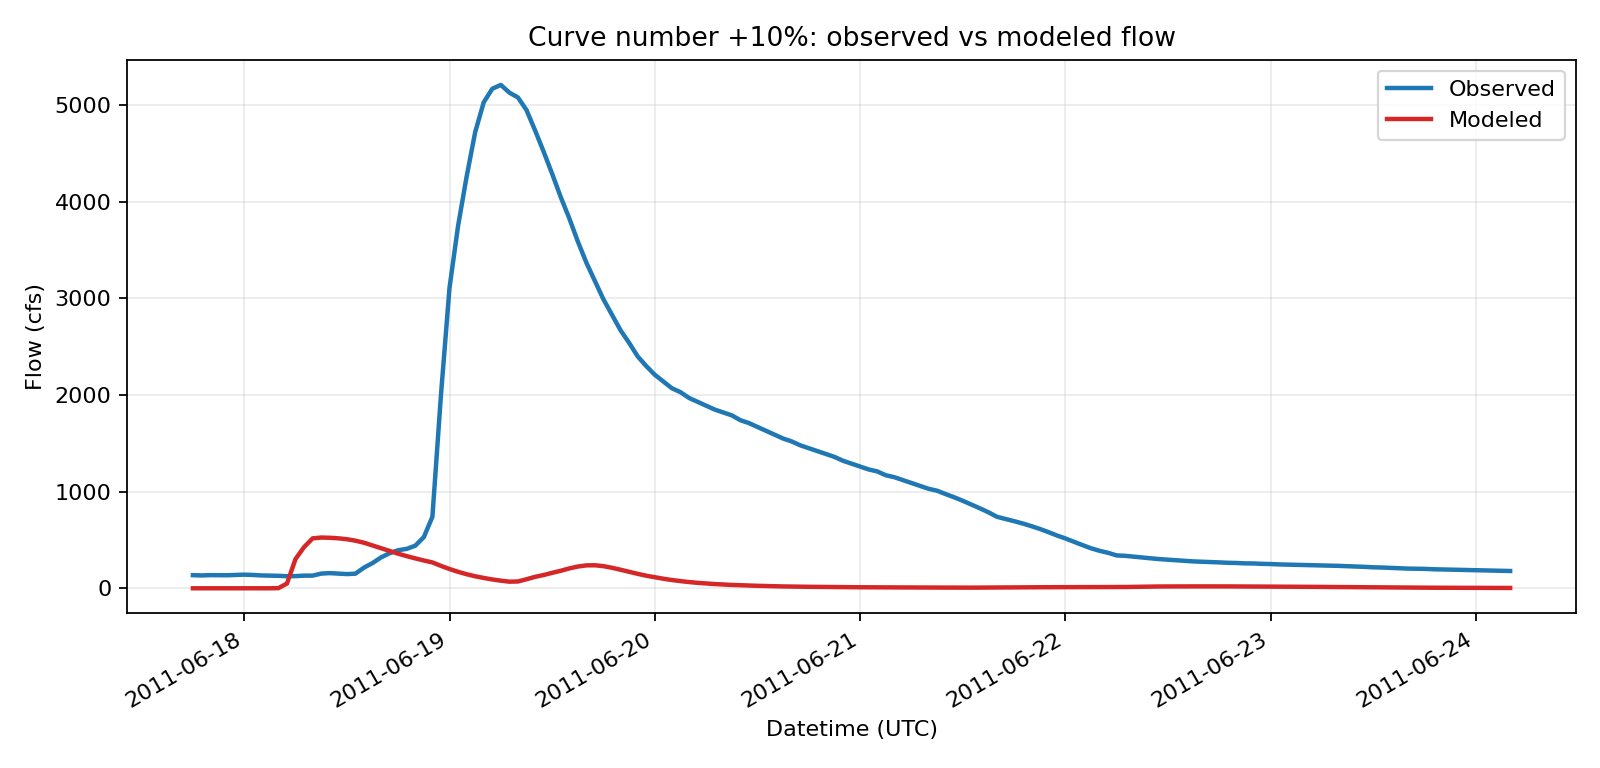

### Best Flow Residual

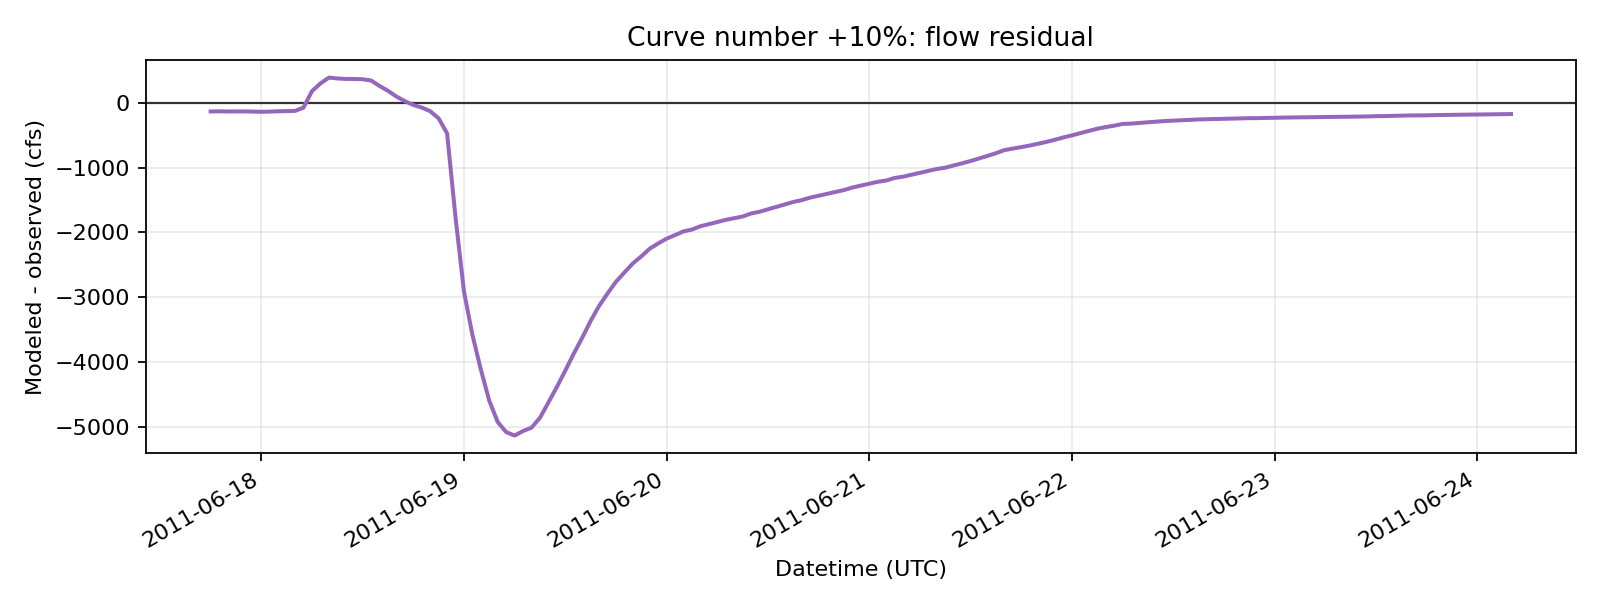

In [10]:
display(Markdown("### Best Observed vs Modeled Flow"))
display(Image(filename=str(OUTPUT_ROOT / "plots" / "best_overlay_flow.png")))
display(Markdown("### Best Flow Residual"))
display(Image(filename=str(OUTPUT_ROOT / "plots" / "best_residual_flow.png")))

### Spatial Manning's n Values

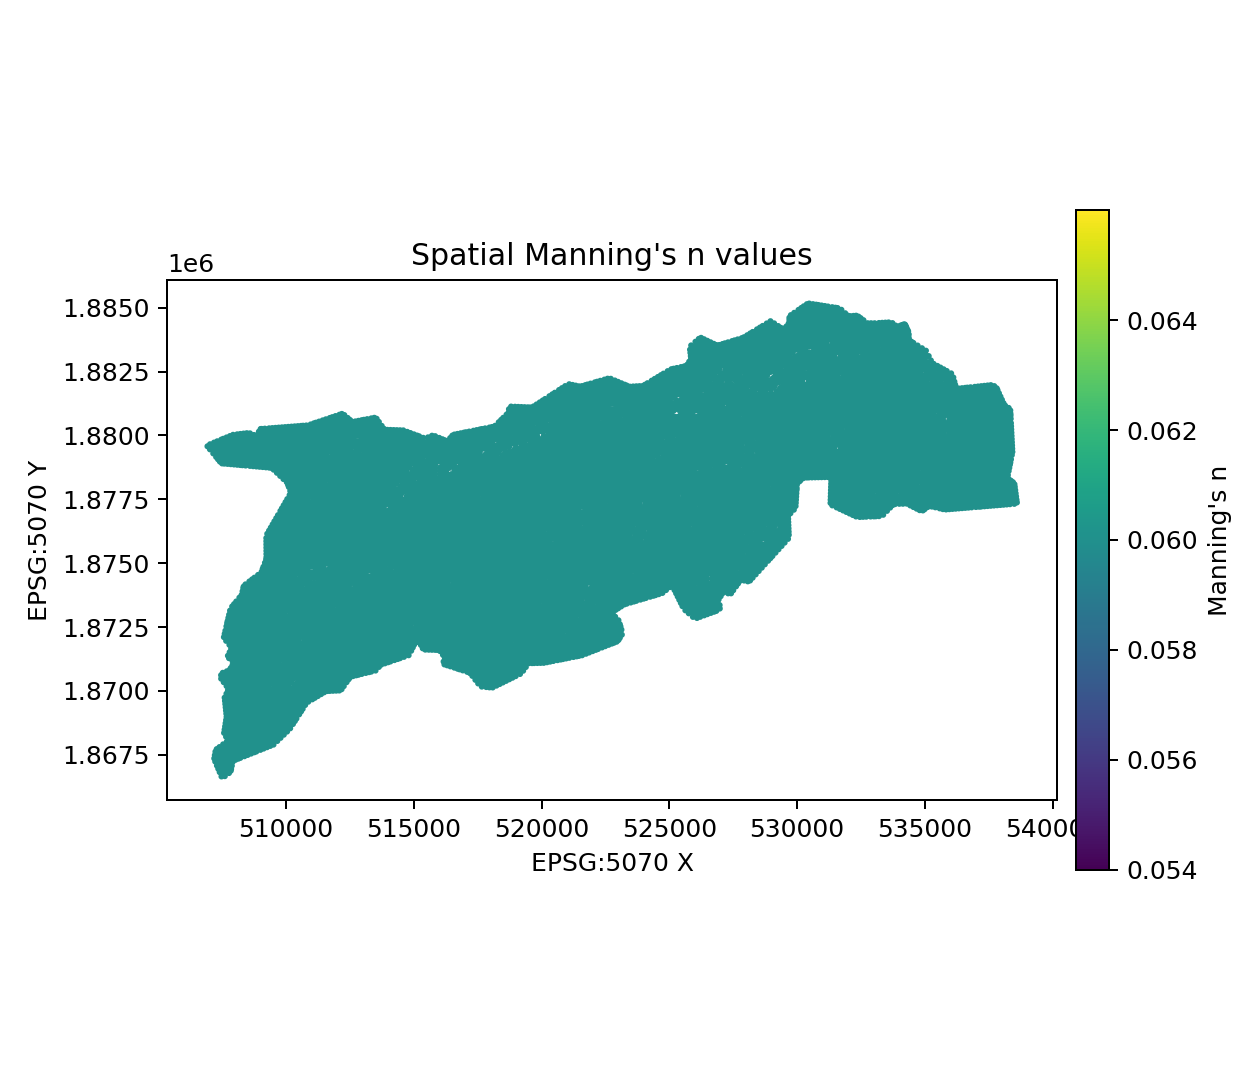

### Spatial Curve Number Values

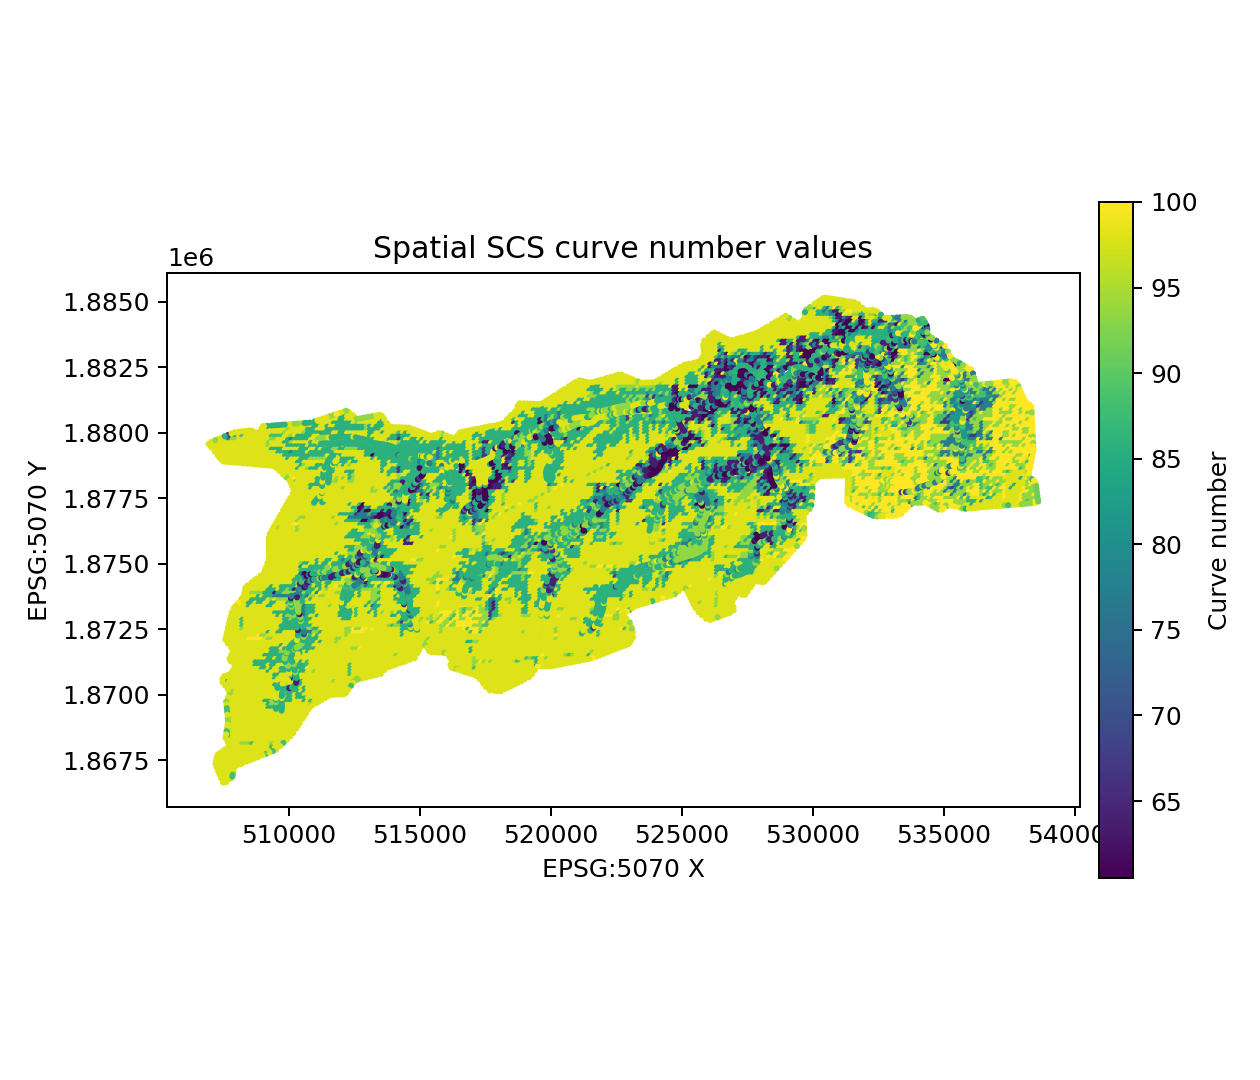

In [11]:
display(Markdown("### Spatial Manning's n Values"))
display(Image(filename=str(OUTPUT_ROOT / "plots" / "mannings_n_map.png")))
display(Markdown("### Spatial Curve Number Values"))
display(Image(filename=str(OUTPUT_ROOT / "plots" / "curve_number_map.png")))

In [12]:
final_parameter_set = metrics.loc[metrics["run"] == best_run, ["run", "label", "mannings_scale", "cn_scale"]]
final_parameter_set

,run,label,mannings_scale,cn_scale
2,curve_number_adjusted,Curve number +10%,1.0,1.1


## 7. Conclusions and Next Steps

The full selected historical event was simulated end to end in HEC-RAS 6.6 over the AORC-aligned window. The first-pass calibration did not reach the NSE target of 0.5; best flow NSE was approximately -0.61, the peak flow was underpredicted by about 90%, and the modeled peak arrived about 21 hours early.

Recommended next steps are to move the spatial CN/infiltration edit into a stable HEC-RAS/`ras-commander` contract, calibrate rain-on-grid losses and roughness through persistent model inputs rather than post-preprocess HDF edits, and validate the gauge extraction against a boundary/profile hydrograph once a stable hydraulic calibration target is available.